Sistema de detección de enlaces spam 

Queremos implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.


Paso 1: Carga del conjunto de datos 

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre url_spam.csv. Puedes cargarlo en el código directamente desde el siguiente enlace: 

https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv O descargarlo y añadirlo a mano en tu repositorio. 


Paso 2: Preprocesa los enlaces 

Utiliza lo visto en este módulo para transformar los datos para compatibilizarlos con el modelo que queremos entrenar. Segmenta las URLs en partes según sus signos de puntuación, elimina las stopwords, lematiza, etcétera. 

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores. 


Paso 3: Construye un SVM 

Comienza a resolver el problema implementando un SVM con los parámetros por defecto. Entrénalo y analiza sus resultados. 


Paso 4: Optimiza el modelo anterior 

Después de entrenar el SVM, optimiza sus hiperparámetros utilizando un grid search o un random search. 


Paso 5: Guarda el modelo 

Almacena el modelo en la carpeta correspondiente.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/url_spam.csv")

In [3]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [4]:
df.shape

(2999, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2999 non-null   str  
 1   is_spam  2999 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 26.5 KB


In [6]:
df.isnull().sum()

url        0
is_spam    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(630)

In [8]:
data = df.copy()

In [9]:
data = data.drop_duplicates()

In [10]:
data.info()

<class 'pandas.DataFrame'>
Index: 2369 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2369 non-null   str  
 1   is_spam  2369 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 39.3 KB


Se eliminan, porque generan sesgo, el modelo memoriza URLs repetidas y aumenta artificialmente el accuracy

In [11]:
data.columns

Index(['url', 'is_spam'], dtype='str')

In [12]:
data["is_spam"].value_counts()

is_spam
False    2125
True      244
Name: count, dtype: int64

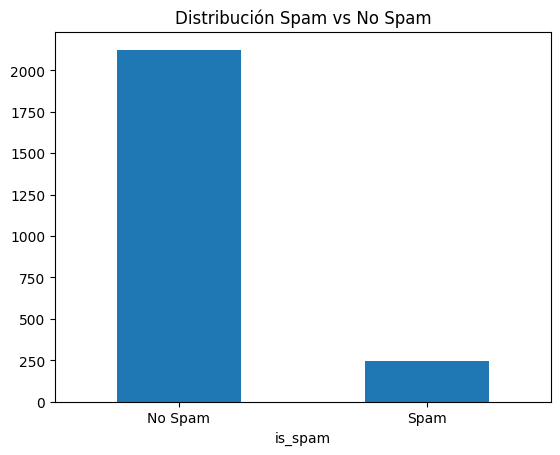

In [15]:
data["is_spam"].value_counts().plot(kind="bar")
plt.title("Distribución Spam vs No Spam")
plt.xticks([0,1],["No Spam","Spam"], rotation=0)
plt.show()

In [16]:
data["url_length"] = df["url"].apply(len)
data["url_length"].describe()

count    2369.000000
mean       78.711693
std        34.822802
min        16.000000
25%        51.000000
50%        77.000000
75%       100.000000
max       269.000000
Name: url_length, dtype: float64

In [ ]:
df[df["is_spam"]==1]["url_length"].hist(alpha=0.5, label="Spam")
df[df["is_spam"]==0]["url_length"].hist(alpha=0.5, label="No Spam")

plt.legend()
plt.title("Longitud de URLs")
plt.show()